# Example 1: Gene expression model

The DynGPT package can be applied to solve a given state transition network and infer the associated model parameters. In this section, we will demonstrate the basic use of DynGPT using the gene expression model as an illustrative example.

<img src="../../_static/image/Figure2.jpg" alt="Schematic of the gene expression central dogma model" width="400" height="200">


In gene expression model, the STN can be described as: <br>
(1) The system state is $s={{\left( {{s}_{\text{OFF}}},{{s}_{\text{ON}}},{{s}_{\text{M}}},{{s}_{\text{P}}} \right)}^{\text{T}}}\in {{\left\{ 0,1 \right\}}^{2}}\times {{\mathbb{N}}^{2}},$ where ${{s}_{\text{OFF}}}$ and ${{s}_{\text{ON}}}$ indicate whether the promoter is in the inactive or active state, ${{s}_{\text{M}}}$ and ${{s}_{\text{P}}}$ are the number of mature RNA and protein molecules, respectively.The system consists of seven events, each associated with a corresponding state transition vectors: <br>
(2)	Event sets are $\mathcal{R}=\left\{ \left. {{\mathcal{R}}_{1}},\ldots ,{{\mathcal{R}}_{7}} \right\} \right.$ where ${{\mathcal{R}}_{1}}$ represents promoter binding, ${{\mathcal{R}}_{2}}$ represents promoter unbinding, ${{\mathcal{R}}_{3}}$ represents active transcription, ${{\mathcal{R}}_{4}}$ represents leaky transcription, ${{\mathcal{R}}_{5}}$ represents degradation of mature RNA, 
${{\mathcal{R}}_{6}}$ represents protein production and ${{\mathcal{R}}_{7}}$ represents protein degradation. <br>
(3) State change vectors are: $\left\{ {{\Delta }^{\left( k \right)}} \right\},k=1,2,\ldots ,7,$ where ${{\Delta }^{\left( k \right)}}=\left( \Delta _{\text{OFF}}^{\left( k \right)},\Delta _{\text{ON}}^{\left( k \right)},\Delta _{\text{M}}^{\left( k \right)},\Delta _{\text{P}}^{\left( k \right)} \right)$ represents the state change vector corresponding to $k\text{-th}$ event with 
$$\begin{align}
  & \Delta _{i}^{\left( 1 \right)}=-{{\delta }_{i,\text{OFF}}}+{{\delta }_{i,\text{ON}}},\text{ } \\ 
 & \Delta _{i}^{\left( 2 \right)}={{\delta }_{i,\text{OFF}}}-{{\delta }_{i,\text{ON}}}, \\ 
 & \Delta _{i}^{\left( 3 \right)}={{\delta }_{i,\text{M}}},\text{ } \\ 
 & \Delta _{i}^{\left( 4 \right)}={{\delta }_{i,\text{M}}}, \\ 
 & \Delta _{i}^{\left( 5 \right)}=-{{\delta }_{i,\text{M}}}, \\ 
 & \Delta _{i}^{\left( 6 \right)}={{\delta }_{i,\text{P}}},\text{ } \\ 
 & \Delta _{i}^{\left( 7 \right)}=-{{\delta }_{i,\text{P}}}, \\ 
\end{align}$$
where $i\in \left\{ \text{OFF},\text{ON},\text{M},\text{P} \right\}$ and ${{\delta }_{i,j}}$ is the Kronecker delta. <br>
(4) The corresponding occurrence propensities of events depend on the current promoter state, mature RNA and protein counts are: ${{\lambda }_{1}}={{k}_{\text{on}}}{{s}_{\text{OFF}}}$, ${{\lambda }_{2}}={{k}_{\text{off}}}{{s}_{\text{ON}}}$, ${{\lambda }_{3}}=k_{\text{syn}}^{\text{on}}{{s}_{\text{ON}}}$, ${{\lambda }_{4}}=k_{\text{syn}}^{\text{off}}{{s}_{\text{OFF}}}$, ${{\lambda }_{5}}=k_{\text{syn}}^{\text{M}}{{s}_{\text{M}}}$, ${{\lambda }_{6}}=k_{\text{deg}}^{\text{M}}{{s}_{\text{M}}}$, ${{\lambda }_{7}}=k_{\text{deg}}^{\text{P}}{{s}_{\text{P}}}$. <br>
In this STN, the parameters are ${{\theta }_{\text{dyn}}}=\left\{ {{k}_{\text{on}}},{{k}_{\text{off}}},k_{s\text{yn}}^{\text{off}},k_{\text{syn}}^{\text{on}},k_{\text{syn}}^{\text{M}},k_{\text{deg}}^{\text{M}},k_{\text{deg}}^{\text{P}} \right\}$.

### 1. Construct configuration file

To facilitate data generation and subsequent neural network training, we need create a configuration file for the gene expression model that encapsulates its key properties. The key propertie of the model primarily consists of the following components:<br>
(1) State-related configuration: This includes the names of the states. In central dogma model, the state names (`state_names`) are: ("ON", "OFF", "mRNA", "Protein") <br>
(2) Event-related configuration: The occurrence rate functions governing event dynamics, and state transition vectors associated with each event's occurrence. In central dogma model, the state transition vectors (`state_transition`) are: $\Delta _{i}^{\left( 1 \right)}$, $\Delta _{i}^{\left( 2 \right)}$, $\Delta _{i}^{\left( 3 \right)}$, $\Delta _{i}^{\left( 4 \right)}$, $\Delta _{i}^{\left( 5 \right)}$, $\Delta _{i}^{\left( 6 \right)}$ and $\Delta _{i}^{\left( 7 \right)}$. Occurrence rates for each event (`event_rates`) are: ${{\lambda }_{1}}={{k}_{\text{on}}}{{s}_{\text{OFF}}}$, ${{\lambda }_{2}}={{k}_{\text{off}}}{{s}_{\text{ON}}}$, ${{\lambda }_{3}}=k_{\text{syn}}^{\text{on}}{{s}_{\text{ON}}}$, ${{\lambda }_{4}}=k_{\text{syn}}^{\text{off}}{{s}_{\text{OFF}}}$, ${{\lambda }_{5}}=k_{\text{syn}}^{\text{M}}{{s}_{\text{M}}}$, ${{\lambda }_{6}}=k_{\text{deg}}^{\text{M}}{{s}_{\text{M}}}$, ${{\lambda }_{7}}=k_{\text{deg}}^{\text{P}}{{s}_{\text{P}}}$. Specifically, in certain events, specific states actively participate and drive the occurrence of the event without changing their own identity. Such a state is referred to as an `drive_state` in the context of the event. In ${{R}_{3}}$ $({{R}_{4}})$, ON (OFF) can be described as drive state, as its presence is essential for initiating the mRNA transciption while remaining unchanged in the event. In ${{R}_{6}}$, mRNA can be described as a drive state, as it provides the genetic instructions for protein synthesis while remaining unchanged in the event.<br>
(3) Parameter-related configuration: The parameter names and the parameter ranges. In central dogma model, the parameter names (`param_names`) are: ["kon", "koff", "ksynon", "ksynoff", "konM", "kdegM", "kdegP"]. Upper bounds of parameters (`upper_bound_val`) are: [0.1, 0.1, 10, 10, 2, 0.5, 0.4]. Lower bounds of parameters (`lower_bound_val`) are: [0.01, 0.01, 0.01, 0.01, 0.01, 0.2, 0.2].

Additionally, we need to specify several hyperparameters for performing SSA simulations on the model, including the model name (`model_name`), the initial values (`initial_val`), the maximum simulation time (`t_end`), the number of parameter sets to simulate for the training (`train_data_size`) and validation datasets (`valid_data_size`), and the directory for storing the resulting simulation data (`dataset_dir`). Specifically, in the central dogma model, ON and OFF are mutually exclusive, such that their sum is always equal to 1. Consequently, it suffices to record the state value of ON, mRNA, and Protein. Accordingly, we define a subset of state indices corresponding to the state names to extract, referred to as the `minimal_state_indices`.

Hence, the following configuration files can be defined for gene expression central dogma model. And we use Python's json package to store this configuration for subsequent simulation and neural network training.

In [ ]:
import json
config_file =
{
  "state_names": ["ON", "OFF", "mRNA", "Protein"],
  "events": [
    {"state_transition": {"OFF": -1, "ON": 1}, "event_rates": "kon*OFF"},
    {"state_transition": {"ON": -1, "OFF": 1}, "event_rates": "koff*ON"},
    {"state_transition": {"mRNA": 1}, "event_rates": "ksynon*ON", "drive_state": "ON"},
    {"state_transition": {"mRNA": 1}, "event_rates": "ksynoff*OFF", "drive_state": "OFF"},
    {"state_transition": {"Protein": 1}, "event_rates": "ksynM*mRNA", "drive_state": "mRNA"},
    {"state_transition": {"mRNA": -1}, "event_rates": "kdegM*mRNA"},
    {"state_transition": {"Protein": -1}, "event_rates": "kdegP*Protein"}
  ],
  "parameters": {
    "param_names": ["kon", "koff", "ksynon", "ksynoff", "ksynM", "kdegM", "kdegP"],
    "upper_bound_val": [0.1, 0.1, 10, 10, 2, 0.5, 0.4],
    "lower_bound_val": [0.01, 0.01, 0.01, 0.01, 0.01, 0.2, 0.2]
  },
  "model_name": "central_dogma_model",
  "initial_val": [1, 0, 0, 0],
  "t_end": 6000,
  "train_data_size": 10000,
  "valid_data_size": 1000,
  "dataset_dir": "/GPUFS/sysu_jjzhang_1/hzw/academicCode/DynGPTTest/DynGPT/data/ts_txl/",
  "minimal_state_indices": [1, 3, 4]
}
config_path_dynmodel = "your_path_config"
with open(config_path_dynmodel, "w") as file:
    json.dump(config_file, file, indent=4)

### 2. Generate datasets

After generating the configuration file, we construct and simulate the state transition network for gene expression model to obtain the dataset required for training the neural network addressing the model. The simulation is implemented in Julia, which provides higher efficiency for stochastic simulation algorithms (SSA) compared to Python. To generate the training data, execute the following command in the terminal:

In [ ]:
julia simulation.jl /path/to/config.json

### 3. Train DynGPT-Solver

In [1]:
# import packages
import sys
import os
import numpy as np
import json
import matplotlib.pyplot as plt 
from matplotlib.gridspec import GridSpec
import logging
import warnings
root_dir = "/GPUFS/sysu_jjzhang_1/hzw/academicCode/DynGPTTest/DynGPT/"
sys.path.append(root_dir)
os.chdir(root_dir)
import dyngpt as dg
logging.getLogger().setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

To train a neural network for addressing the gene expression model and inferring its parameters, a basic configuration file must first be defined. This file includes four key components: (1) the information of the gene expression model, (2) the neural network architecture, (3) the directory for saving outputs and visualizations, and (4) the default parameter settings for the neural network. Subsequent configurations for training, sampling, and inference build upon this foundation by incorporating additional task-specific parameters as needed. The relationships between the configurations of each subsequent stage are presented as follows:

<img src="../../_static/image/Figure_config.jpg" alt="Schematic of config" width="600" height="200">

Firstly, the basic configuration file must include detailed information about the dynamic model, which has already been stored in the previous configuration file.

In [ ]:
config_basic = {}
config_path_dynmodel = "your_path_config"
model_name = "central_dogma_model"
config_path_dynmodel = "config/{}_config.json".format(model_name)
config_basic = dg.tl.update_dynmodel_config(config_basic,config_path_dynmodel)

Next, the architecture of the neural network is defined by specifying the relevant structural details within the configuration.

In [3]:
config_basic["num_encoder_layers"] = 1  # transformer n_layer
config_basic["n_head"] = 8  # transformer n_head
config_basic["feed_forward_dimension"] = 1024  # transformer feed_forward_dimension

Additionally, we should designate a directory for saving output files and visualizations.

In [4]:
config_basic["dataset_dir"]="your/path/to/saveresult/"
config_basic["figure_dir"]="your/path/to/savefigure/"
config_basic["result_dir"]="result/{}/".format(config_basic["model"])
config_basic["figure_dir"]="figure/{}/".format(config_basic["model"])

Finally, execute the folowing code to append default configuration parameters.

In [5]:
config_basic = dg.tl.update_default_config(config_basic)

After defining the configuration file, we proceed to train the neural network designed to solve the gene expression model. The training process is divided into two stages: the first stage involves pretraining the neural network, while the second stage focuses on fine-tuning it. Additionally, for each stage, we will visualize the corresponding loss function curves to evaluate the training progress.

For model pretraining, the configuration file is extended from the basic configuration. We should specify the number of epochs (`epochs_pretrain`) and the training dataset path (`train_dataset_path`) in the configuration file.

In [ ]:
config_pretrain = config_basic
config_pretrain.epochs_pretrain = 1 # 1000
config_pretrain.train_dataset_path = "your/path/to/train_dataset"
config_pretrain.train_dataset_path = "data/ts_txl/ts_txl_train_stable.json"
result_pre_train = dg.solver.pre_training(config_pretrain)

Visualize the loss values during the pretraining phase of the model.

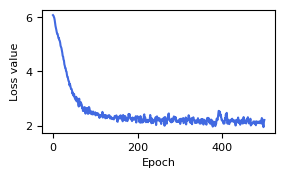

In [6]:
result_pre_train = np.load("tutorials/result/arl/config6/train_loss/arl_epoch500.npz")
dg.pl.plot_loss(result_pre_train["loss_mean"])

During the fine-tuning phase, the configuration file is also extended from the basic configuration, specifying the number of epochs (`epochs_fine_tune`), the training dataset path (`train_dataset_path`), and the pretrained network weights (`weight_nn_pretrain_path`).

In [ ]:
config_fine_tune = config_basic
config_fine_tune.epochs_fine_tune = 1 # 1000
config_fine_tune.train_dataset_path = "your/path/to/train_dataset"
config_fine_tune.train_dataset_path = "data/ts_txl/ts_txl_train_stable.json"
config_fine_tune.weight_nn_pretrain_path = result_pre_train["weight_nn_pretrain_path"]
result_fine_tune = dg.solver.fine_tune_training(config_fine_tune)

Visualize the loss values during the fine tunning phase of the model.

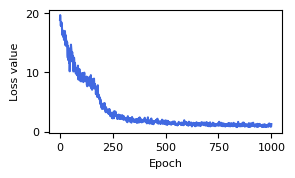

In [7]:
result_fine_tune = np.load("result/central_dogma_model/train_loss/fine_tune_central_dogma_model_epoch1000.npz")
dg.pl.plot_loss(result_fine_tune["loss_mean"])

After the neural network training converges, we valid the performance of the neural network model in solving gene expression model from comparative analysis of the samples generated by the neural network and those obtained through simulations in terms of their mean, standard deviation, and overall distribution. 
When using the trained model for sampling, the configuration file is also extended from the basic configuration, specifying the validation dataset path (`valid_dataset_path`) and incorporating the fine-tuned network weights (`weight_nn_fine_tune_path`).

In [8]:
config_sampling = config_basic
valid_dataset_path =  "your/valid/datasetpath/"
valid_dataset_path =  "data/ts_txl/ts_txl_valid_stable.json"
# config_sampling.weight_nn_fine_tune_path = result_fine_tune["weight_nn_fine_tune_path"]
config_sampling.weight_nn_fine_tune_path = "/GPUFS/sysu_jjzhang_1/hzw/academicCode/DynGPTTest/DynGPT/dyngpt/_weights/ts_txl_final.pt"
config_sampling.valid_dataset_path = valid_dataset_path
result_valid_set = dg.tl.compute_sampling_stats(config_sampling)

the indices length is 100


We visualize the performance of the neural network model on the validation set. This includes a comparative analysis of the samples generated by the neural network and those obtained through simulations in terms of their mean, standard deviation, and overall distribution.

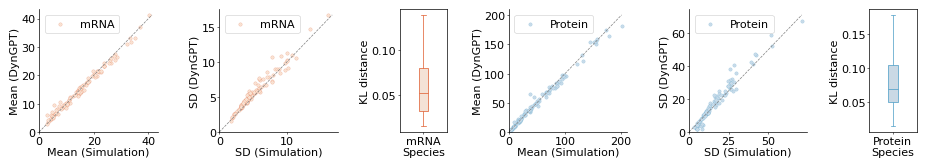

In [9]:
dg.pl.plot_model_comparison_stats(result_valid_set,state_index=[1,2])

In [12]:
result_valid_set["state_name"]=['mRNA', 'Protein', 'Protein']

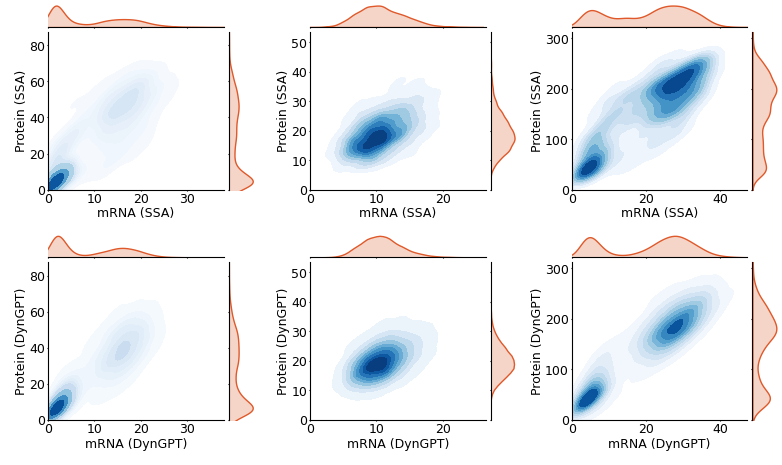

In [13]:
dg.pl.plot_distribution_comparison_2d(result_valid_set,data_index = [12,15,16])

### 4. Infer the parameters with DynGPT-Inferrer

In this section, we employ the trained model to infer the corresponding stochastic dynamics from the observed data.

In [15]:
observed_dataset_path =  "your/observed/datasetpath/"
observed_dataset_path =  "data/ts_txl/ts_txl_valid_stable.json"
observed_data,true_params = dg.tl.load_synthetic_data(observed_dataset_path,params_number=100) 

For the inference process, the configuration file is also extended from the basic configuration, defining the following hyperparameters: the trained neural network parameters path (`weight_nn_fine_tune_path`), the loss function (`inference_loss_func`), the learning rate (`inference_lr`), the maximum number of iterations (`iteration_steps`), the initial number of parameters sampled from the prior distribution (`random_r0_number`), and the threshold for parameter acceptance (`param_acceptance_threshold`).

In [16]:
config_infer = config_basic
# config_infer.weight_nn_fine_tune_path = result_fine_tune["weight_nn_fine_tune_path"]
config_infer.weight_nn_fine_tune_path = "/GPUFS/sysu_jjzhang_1/hzw/academicCode/DynGPTTest/DynGPT/dyngpt/_weights/ts_txl_final.pt"
config_infer.inference_loss_func = "Likelihood"
config_infer.inference_lr = 0.0001
config_infer.iteration_steps = 80
config_infer.random_r0_number = 2
config_infer.param_acceptance_threshold = 0.5 
result_infer = dg.inferrer.inferring_dynamics(observed_data,config_infer,new_model=True,synthetic_flag=True)

We visualize the performance of the neural network model on the observed dataset. This includes a comparative analysis of the samples generated by the estimated parameters of gene expression model and those obtained through simulations in terms of their mean and overall distribution.

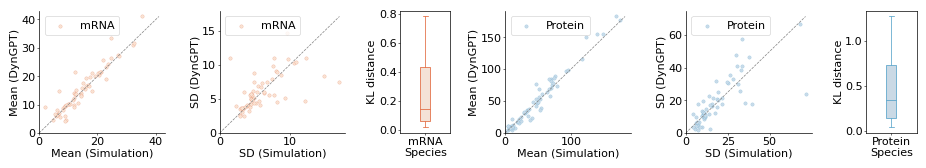

In [17]:
result_dict = dg.tl.compute_kl_stats(result_infer)
dg.pl.plot_model_comparison_stats(result_dict,state_index=[1,2])

We visualize the distribution obtained from the observational data with the distribution corresponding to the inferred dynamical parameters.

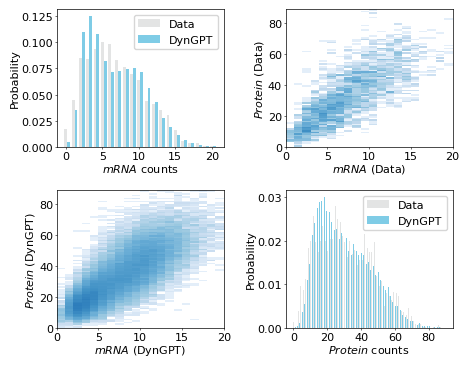

In [28]:
dg.pl.plot_distribution_comparison_nd(result_infer,species_index=[1,2],data_index=[4],width_mm=120)

We visualize the posterior distribution of the inferred dynamical model parameters.

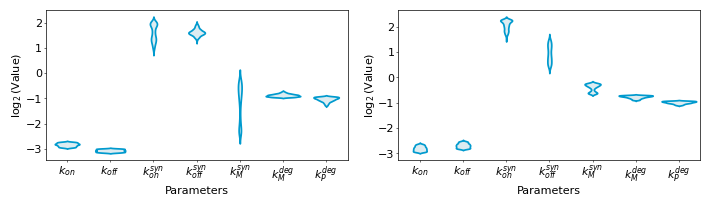

In [25]:
result_infer["param_names"] = np.array([r"$k_{on}$", "$k_{off}$",r"$k_{on}^{syn}$",  r"$k_{off}^{syn}$", r"$k_{M}^{syn}$", r"$k_{M}^{deg}$", r"$k_{P}^{deg}$"])
dg.pl.plot_param_posterior_dist(result_infer,param_indexes=[45,54])